와인 데이터셋 불러오기 및 확인


[wine_tree.py 작성: 20점]
sklearn 와인 데이터 셋에서 alcohol과 malic acid 특성만을 사용해 와인의 등급을
decision tree로 분류하자. 이때 데이터 셋을 sklearn.model_selection 모듈의 train_test_split을 사용해
8:2의 비율로 train:test로 분할하되, 난수(random_state)로 2222 값을 적용하시오.

test 데이터 셋을 적용한 confusion matrix와 classification_report를 출력하고, matplotlib.pyplot 모듈의
plot_tree를 사용하여 ‘depth=3’인 decision tree를 그리시오.

----------------------------------------------------------------------
[wine_alcohol_roc.py 작성: 35점]
와인 데이터셋에서 등급이 0과 1인 데이터만을 남기고
등급이 2인 데이터는 제거한 데이터 셋을 준비하시오
앞 서와 마찬가지로 alcohol과 malic acid 특성을
활용하여 와인의 등급(0과 1)을 분류하는데, alcoholed malic acid라는 지표를 𝑎𝑙𝑐𝑜ℎ𝑜𝑙𝑒𝑑 𝑚𝑎𝑙𝑖𝑐 𝑎𝑐𝑖𝑑 = √𝑎𝑙𝑐𝑜ℎ𝑜𝑙 ∙ (𝑚𝑎𝑙𝑖𝑐 𝑎𝑐𝑖𝑑) 식을 통해 계산하여 활용하자.

alcoholed malic acid 값을 9.0 ~ 24.0까지 0.1씩 증가시키면서 등급이 1인 와인을 찾아내는
경우의 ROC 곡선을 그려내고, 와인의 등급을 0과 1로 분류할 때 가장 높은 성능을 보이는 alcoholed
malic acid의 기준값(threshold)을 제시하시오.

In [ ]:
from sklearn import datasets
dataset = datasets.load_wine()

from sklearn.neighbors import KNeighborsClassifier

# 입력 변수: Alcohol과 Malic Acid 2개만 선택 (2D 시각화와 연결됨)
x_train = d[['alcohol', 'malic_acid']]

# 출력 변수 (정답 레이블): target 열
y_train = d['target']

# KNN 분류기 객체 생성, K=3 (3개의 이웃을 기준으로 다수결)
model = KNeighborsClassifier(n_neighbors=5)

# 모델 학습 (입력값과 정답값으로)
model.fit(x_train, y_train)

# 새로운 와인 데이터 한 개 예측 (알코올 도수 12, 말산 함량 3)
predicted_class = model.predict([[12, 3]])

# 예측 결과 출력 (예: [0] → class_0)
print("예측 결과:", predicted_class)


# =============================
# --- 의사결정나무 모델 생성 및 학습 ---

from sklearn.tree import DecisionTreeClassifier

# 🌳 의사결정나무 모델 생성 (random_state 고정으로 트리 구조 고정)
dtc = DecisionTreeClassifier(random_state=2222)

# 🧠 학습: 훈련 데이터를 기반으로 트리 분기 규칙 생성
dtc.fit(x_train, y_train)

# 🤖 예측: 테스트 데이터를 모델에 넣고 이탈 여부 예측
y_pred = dtc.predict(x_test)

NameError: name 'd' is not defined

In [12]:
# scikit-learn 내장 데이터셋 중 '와인' 데이터셋을 불러옴
from sklearn import datasets
dataset = datasets.load_wine()

# 데이터셋 전체 설명 출력 (데이터의 구조, 특성 설명 등 텍스트)
print(dataset.DESCR)

# 특성값만 출력 (입력값, 즉 13개의 와인 특성)
print(dataset.data)

# 데이터 구조 확인: numpy 배열 형태로 제공됨
print(type(dataset.data))  # <class 'numpy.ndarray'>

# 데이터의 차원 확인: 178개의 와인 샘플, 13개의 특성(feature)
print(dataset.data.shape)  # (178, 13)

# 첫 번째 와인 샘플의 13개 특성값 출력
print(dataset.data[0])

# 특성 이름(열 이름) 리스트 출력
print(dataset.feature_names)

# 정답(label)값 출력: 0, 1, 2로 세 가지 와인 등급을 의미
print(dataset.target)

# 정답값의 의미 (각 등급의 이름)
print(dataset.target_names)  # ['class_0', 'class_1', 'class_2']

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

데이터프레임 변환 및 시각화 준비

In [13]:
import pandas as pd

# 데이터프레임으로 변환하여 열 이름 지정
d = pd.DataFrame(dataset.data, columns=dataset.feature_names)

# 정답값(target)을 'target' 열로 추가
d['target'] = dataset.target

2차원 산점도 시각화 (Alcohol vs Malic Acid)

/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N

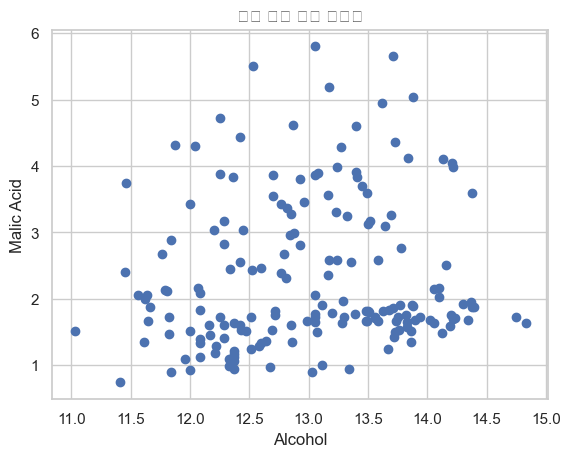

In [14]:
import matplotlib.pyplot as plt

# 두 개의 특성으로 간단한 산점도 시각화
plt.scatter(d['alcohol'], d['malic_acid'])
plt.xlabel('Alcohol')       # x축 레이블
plt.ylabel('Malic Acid')    # y축 레이블
plt.title('전체 와인 샘플 산점도')
plt.show()

와인 등급별 색상 구분 산점도

/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


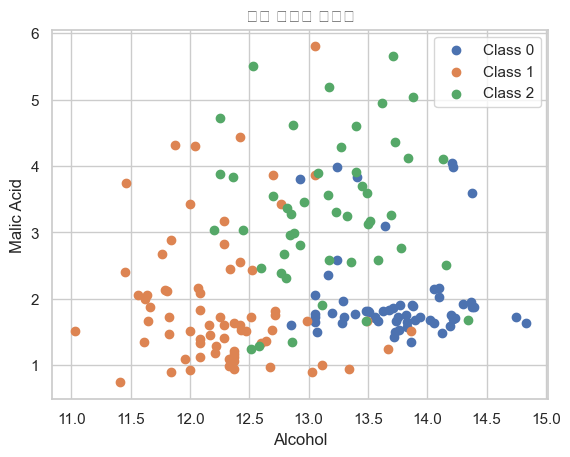

In [15]:
# target 기준으로 그룹 나누기
grouped = d.groupby('target')

# 각 그룹(등급)마다 산점도를 다르게 그리기
for group_name, group_data in grouped:
    # 각 그룹별로 다른 색과 라벨로 점 찍기
    plt.scatter(group_data['alcohol'], group_data['malic_acid'], label=f'Class {group_name}')

plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.title('와인 등급별 산점도')
plt.legend()  # 범례 표시
plt.show()

 3차원 시각화

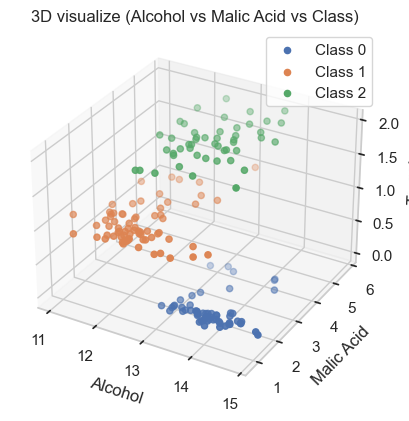

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # 3D 플롯을 위한 모듈

# 3D 플롯 생성
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 등급별로 색을 나눠서 3차원 플롯 그리기
for group_name, group_data in grouped:
    # Z축에 'target'값을 그대로 사용하여 class별 위치 표현
    ax.scatter(group_data['alcohol'], group_data['malic_acid'], group_name, label=f'Class {group_name}')

ax.set_xlabel('Alcohol')
ax.set_ylabel('Malic Acid')
ax.set_zlabel('Target')
plt.title('3D visualize (Alcohol vs Malic Acid vs Class)')
plt.legend()
plt.show()

KNN 모형 생성 및 예측

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# 입력 변수: Alcohol과 Malic Acid 2개만 선택 (2D 시각화와 연결됨)
x_train = d[['alcohol', 'malic_acid']]

# 출력 변수 (정답 레이블): target 열
y_train = d['target']

# KNN 분류기 객체 생성, K=5 (5개의 이웃을 기준으로 다수결)
model = KNeighborsClassifier(n_neighbors=5)

# 모델 학습 (입력값과 정답값으로)
model.fit(x_train, y_train)

# 새로운 와인 데이터 한 개 예측 (알코올 도수 12, 말산 함량 3)
predicted_class = model.predict([[12, 3]])

# 예측 결과 출력 (예: [0] → class_0)
print("예측 결과:", predicted_class)

예측 결과: [1]


/Users/juns/business_analytics/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


*아래는 모의고사 로직 실습 

In [ ]:
# Step 1. 라이브러리 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Step 2. 데이터 불러오기
#df = pd.read_csv('wine.csv')

# Step 3. X (입력값) / y (정답값) 분리
X = df.drop('target', axis=1)
y = df['target']

# Step 4. 학습용 / 테스트용 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5. KNN 모델 생성 및 학습
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Step 6. 예측
y_pred = knn.predict(X_test)

# Step 7. 정확도 평가
acc = accuracy_score(y_test, y_pred)
print("정확도:", acc)

In [7]:
!pip install pandas numpy matplotlib seaborn scikit-learn ipykernel

정확도: 0.9444444444444444


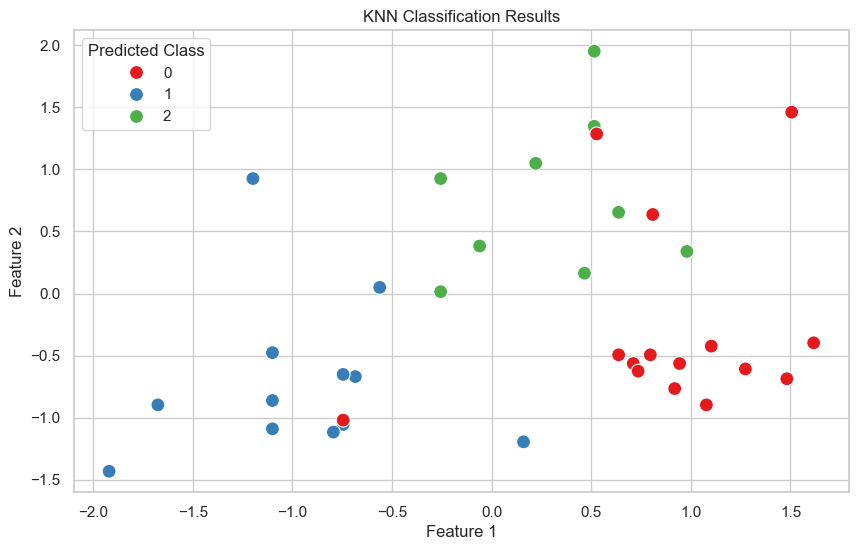

불러온 모델의 정확도: 0.9444444444444444


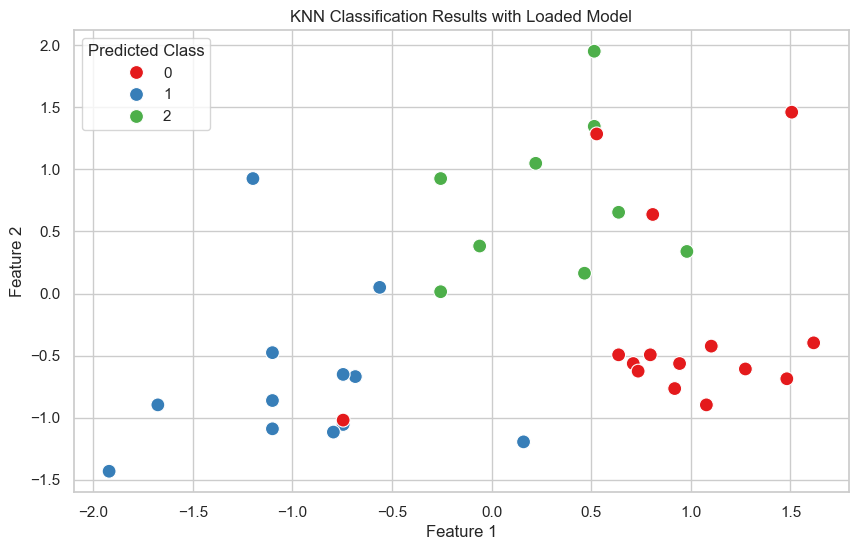

기존 모델의 정확도: 0.9444444444444444
불러온 모델의 정확도: 0.9444444444444444


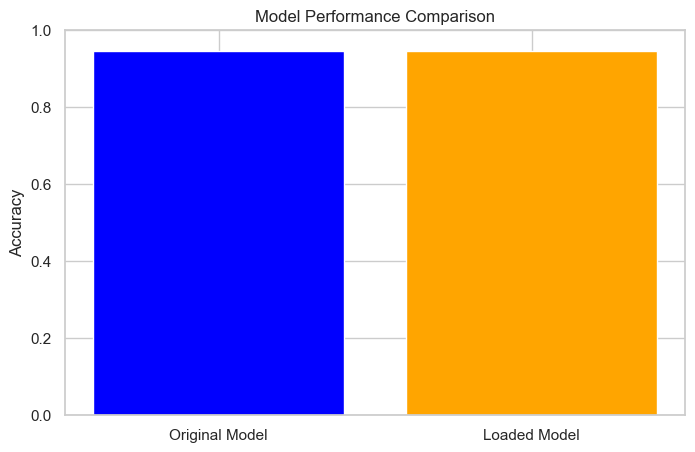

            Model  Accuracy
0  Original Model  0.944444
1    Loaded Model  0.944444


In [8]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Step 1. 데이터 불러오기
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
# Step 2. X (입력값) / y (정답값) 분리

X = df.drop('target', axis=1)
y = df['target']
# Step 3. 학습용 / 테스트용 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Step 4. 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Step 5. KNN 모델 생성 및 학습
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
# Step 6. 예측
y_pred = knn.predict(X_test)
# Step 7. 정확도 평가
acc = accuracy_score(y_test, y_pred)
print("정확도:", acc)
# Step 8. 예측 결과 시각화
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred, palette="Set1", s=100)
plt.title("KNN Classification Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Predicted Class")
plt.show()
# Step 9. 모델 저장
import joblib
joblib.dump(knn, 'knn_model.pkl')
# Step 10. 모델 불러오기
loaded_model = joblib.load('knn_model.pkl')
# Step 11. 불러온 모델로 예측
y_pred_loaded = loaded_model.predict(X_test)
# Step 12. 불러온 모델의 정확도 평가
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print("불러온 모델의 정확도:", acc_loaded)
# Step 13. 예측 결과 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_loaded, palette="Set1", s=100)
plt.title("KNN Classification Results with Loaded Model")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Predicted Class")
plt.show()
# Step 14. 모델 성능 비교
# 기존 모델과 불러온 모델의 정확도 비교
print("기존 모델의 정확도:", acc)
print("불러온 모델의 정확도:", acc_loaded)
# Step 15. 모델 성능 비교 시각화
import matplotlib.pyplot as plt
import numpy as np
# 정확도 비교를 위한 데이터 준비
model_names = ['Original Model', 'Loaded Model']
accuracies = [acc, acc_loaded]
# 막대 그래프 그리기
plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies, color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.show()
# Step 16. 모델 성능 비교 표
performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})
print(performance_df)


In [ ]:
# wine_tree.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 와인 데이터셋 로드
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)[['alcohol', 'malic_acid']]
y = wine.target

# 데이터 8:2로 분할 (random_state=2222)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2222)

# Decision Tree 모델 생성 및 학습 (max_depth=3)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=2222)
dt_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = dt_model.predict(X_test)

# Confusion Matrix 출력
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Decision Tree 시각화
plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=['alcohol', 'malic_acid'],
          class_names=['class_0', 'class_1', 'class_2'],
          filled=True,
          rounded=True)
plt.savefig('wine_decision_tree.png')
plt.show()

# wine_alcohol_roc.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 와인 데이터셋 로드
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# 클래스 0과 1만 선택
df = df[df['target'].isin([0, 1])]

# alcoholed malic acid 계산
def calculate_alcoholed_malic_acid(alcohol, malic_acid):
    return np.sqrt(alcohol * malic_acid)

df['alcoholed_malic_acid'] = calculate_alcoholed_malic_acid(
    df['alcohol'], df['malic_acid']
)

# ROC 커브를 위한 데이터 준비
y_true = df['target']
scores = df['alcoholed_malic_acid']

# 임계값 범위 설정 (9.0 ~ 24.0, 0.1 간격)
thresholds = np.arange(9.0, 24.1, 0.1)

# ROC 커브 계산
fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

# ROC 커브 그리기
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Wine Classification')
plt.legend(loc="lower right")

# 최적의 임계값 찾기
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = roc_thresholds[optimal_idx]

print(f"최적의 alcoholed malic acid 임계값: {optimal_threshold:.2f}")

plt.savefig('wine_roc_curve.png')
plt.show()

최적의 alcoholed malic acid 임계값: 5.61


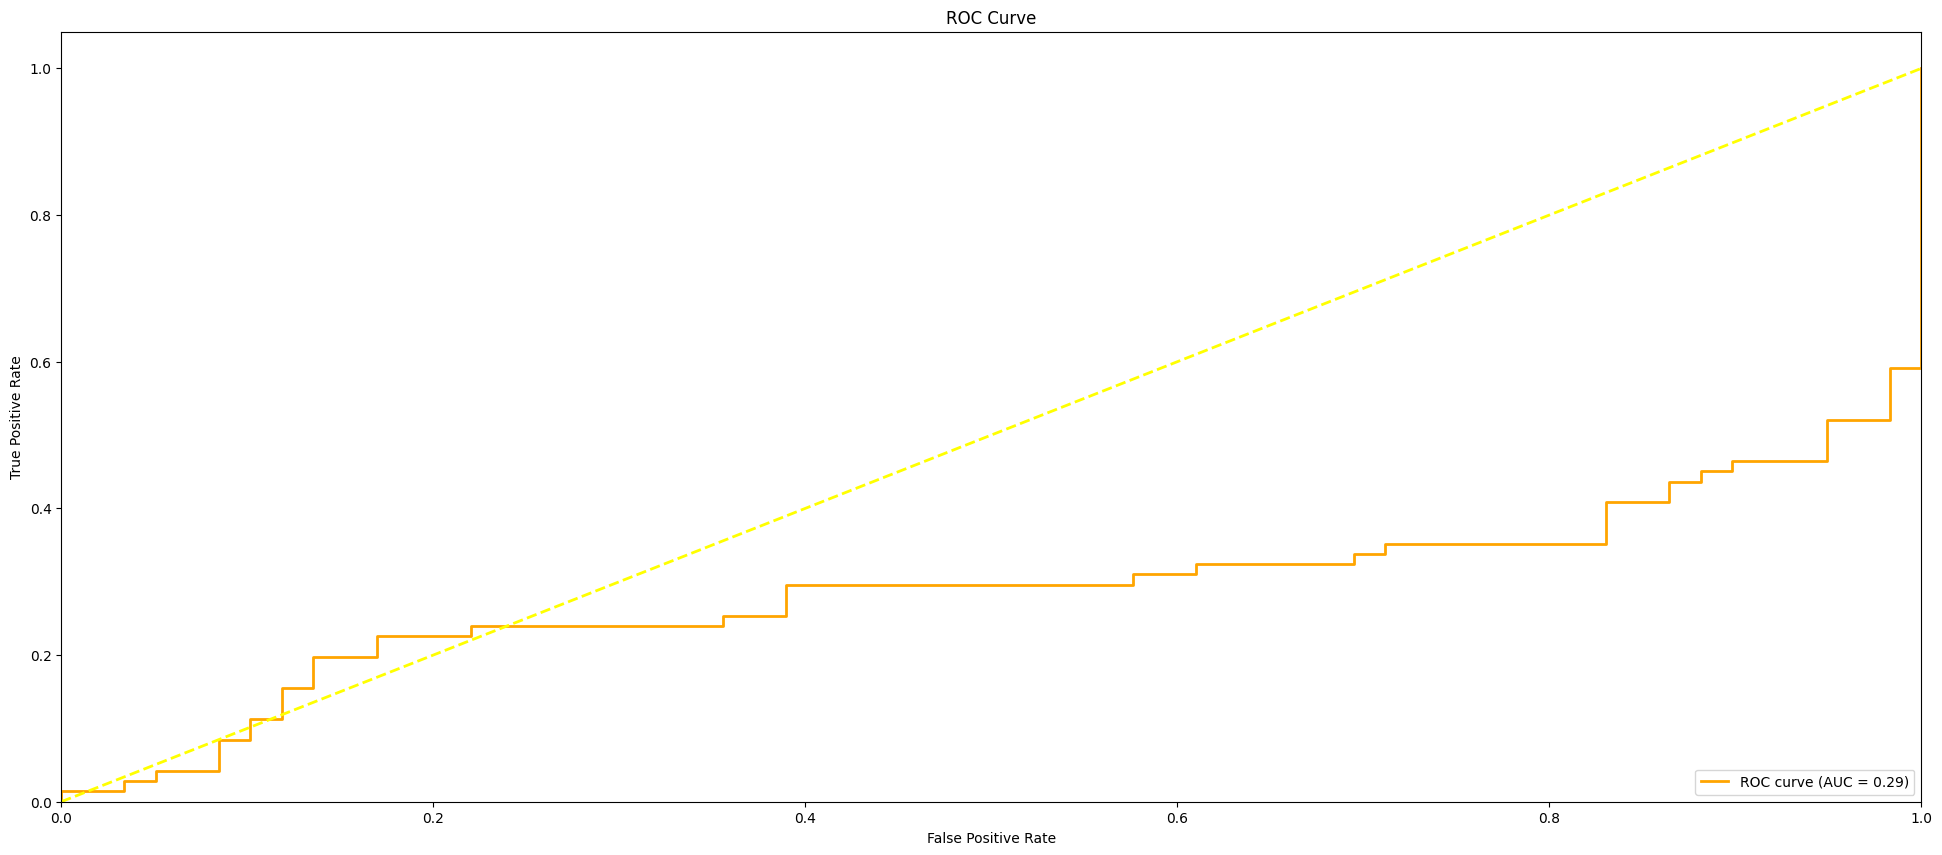

In [ ]:
# wine_alcohol_roc.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 와인 데이터셋 로드
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

"""이번에는 와인 데이터셋에서 등급이 0과 1인 데이터만을 남기고
등급이 2인 데이터는 제거한 데이터 셋을 준비하시오"""

# 클래스 0과 1만 선택
df = df[df['target'].isin([0, 1])]

# alcoholed malic acid 계산
def calculate_alcoholed_malic_acid(alcohol, malic_acid):
    return np.sqrt(alcohol * malic_acid)

df['alcoholed_malic_acid'] = calculate_alcoholed_malic_acid(
    df['alcohol'], df['malic_acid']
)

# ROC 커브를 위한 데이터 준비
y_true = df['target']
scores = df['alcoholed_malic_acid']

"""" alcoholed malic acid라는 지표를 아래의 식을 통해 계산하여
활용하자. alcoholed malic acid 값을 9.0 ~ 24.0까지 0.1씩 증가시키면서 등급이 1인 와인을 찾아내는
경우의 ROC 곡선을 그려내고, 와인의 등급을 0과 1로 분류할 때 가장 높은 성능을 보이는 alcoholed
malic acid의 기준값(threshold)을 제시하시오"""

# 임계값 범위 설정 (9.0 ~ 24.0, 0.1 증가)
thresholds = np.arange(9.0, 24.1, 0.1)

# ROC 커브 계산
fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

# ROC 커브 그리기
plt.figure(figsize=(24, 10))
plt.plot(fpr, tpr, color='orange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='yellow', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# 최적의 임계값 찾기
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = roc_thresholds[optimal_idx]

print(f"최적의 alcoholed malic acid 임계값: {optimal_threshold:.2f}")

plt.savefig('wine_roc_curve.png')
plt.show()

Confusion Matrix:
[[ 9  0  1]
 [ 1 13  1]
 [ 1  3  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.81      0.87      0.84        15
           2       0.78      0.64      0.70        11

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.80      0.81      0.80        36



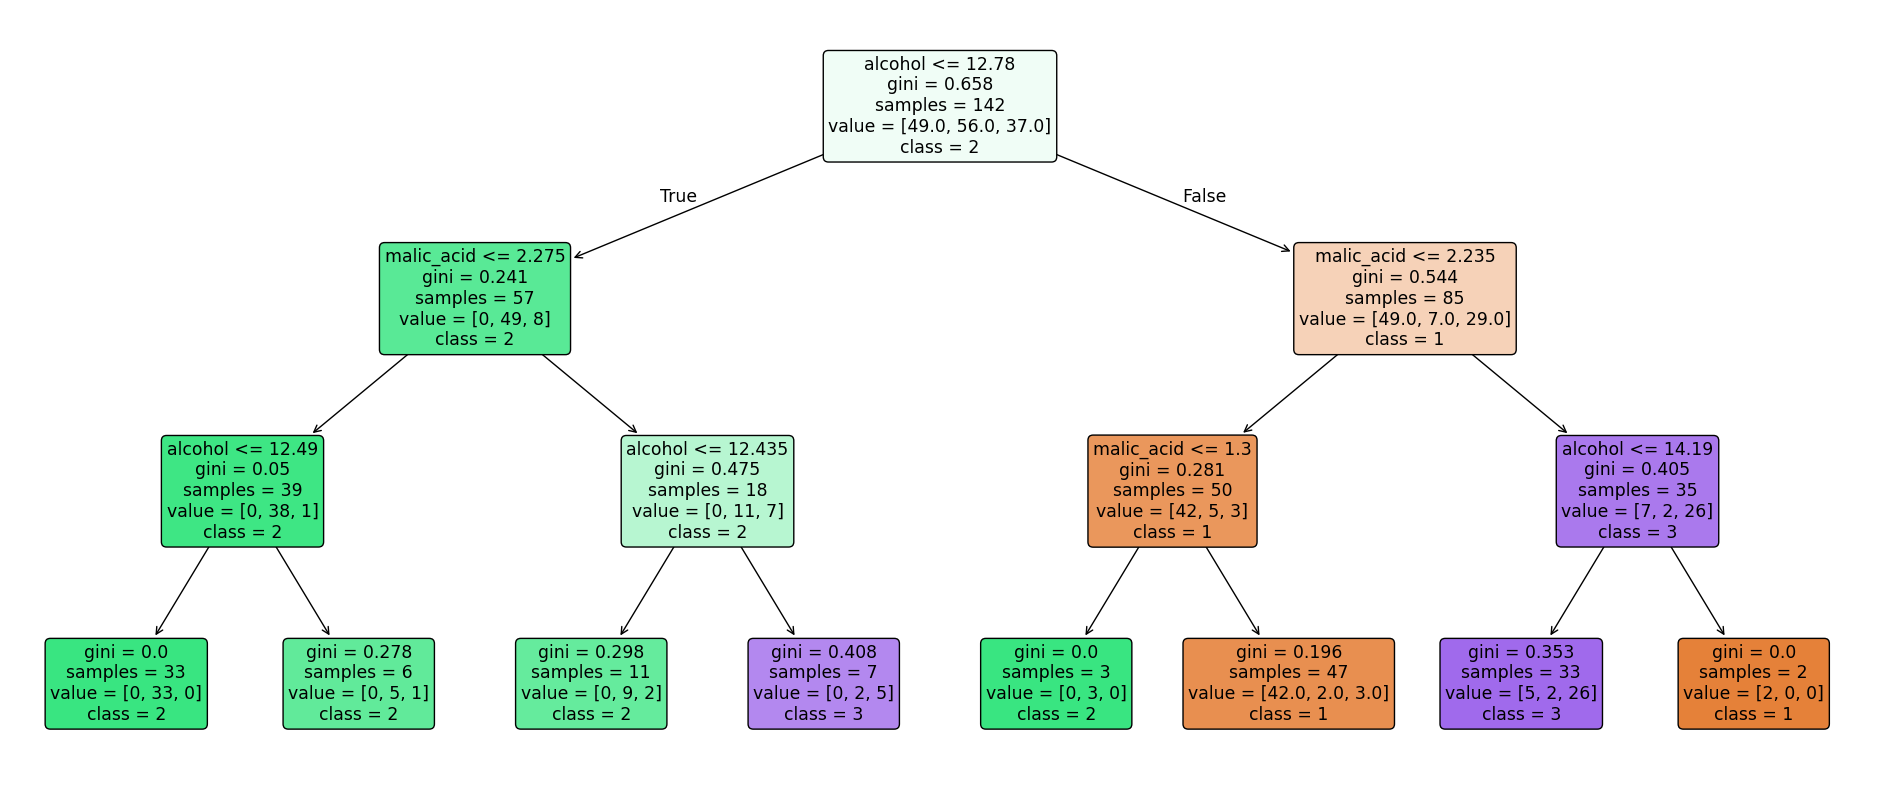

In [4]:

# wine_tree.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 와인 데이터셋 로드
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)[['alcohol', 'malic_acid']]
y = wine.target

"""이때 데이터 셋을 sklearn.model_selection 모듈의 train_test_split을 사용해
8:2의 비율로 train:test로 분할하되, 난수(random_state)로 2222 값을 적용"""

# 데이터 8:2로 분할 (random_state=2222)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2222)

"""matplotlib.pyplot 모듈의
plot_tree를 사용하여 ‘depth=3’인 decision tree"""

# Decision Tree 모델 생성 및 학습 (max_depth=3)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=2222)
dt_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = dt_model.predict(X_test)

"""test
데이터 셋을 적용한 confusion matrix와 classification_report를 출력"""

# Confusion Matrix 출력
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

"""matplotlib.pyplot 모듈의
plot_tree를 사용하여 ‘depth=3’인 decision tree"""

# Decision Tree 시각화
# 그래프 크기 설정
plt.figure(figsize=(24, 10))
plot_tree(dt_model,
          feature_names=['alcohol', 'malic_acid'],
          class_names=['1', '2', '3'],
          filled=True,
          rounded=True)
plt.savefig('wine_decision_tree.png')
plt.show()

Confusion Matrix:
[[ 9  0  1]
 [ 1 13  1]
 [ 1  3  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.81      0.87      0.84        15
           2       0.78      0.64      0.70        11

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.80      0.81      0.80        36



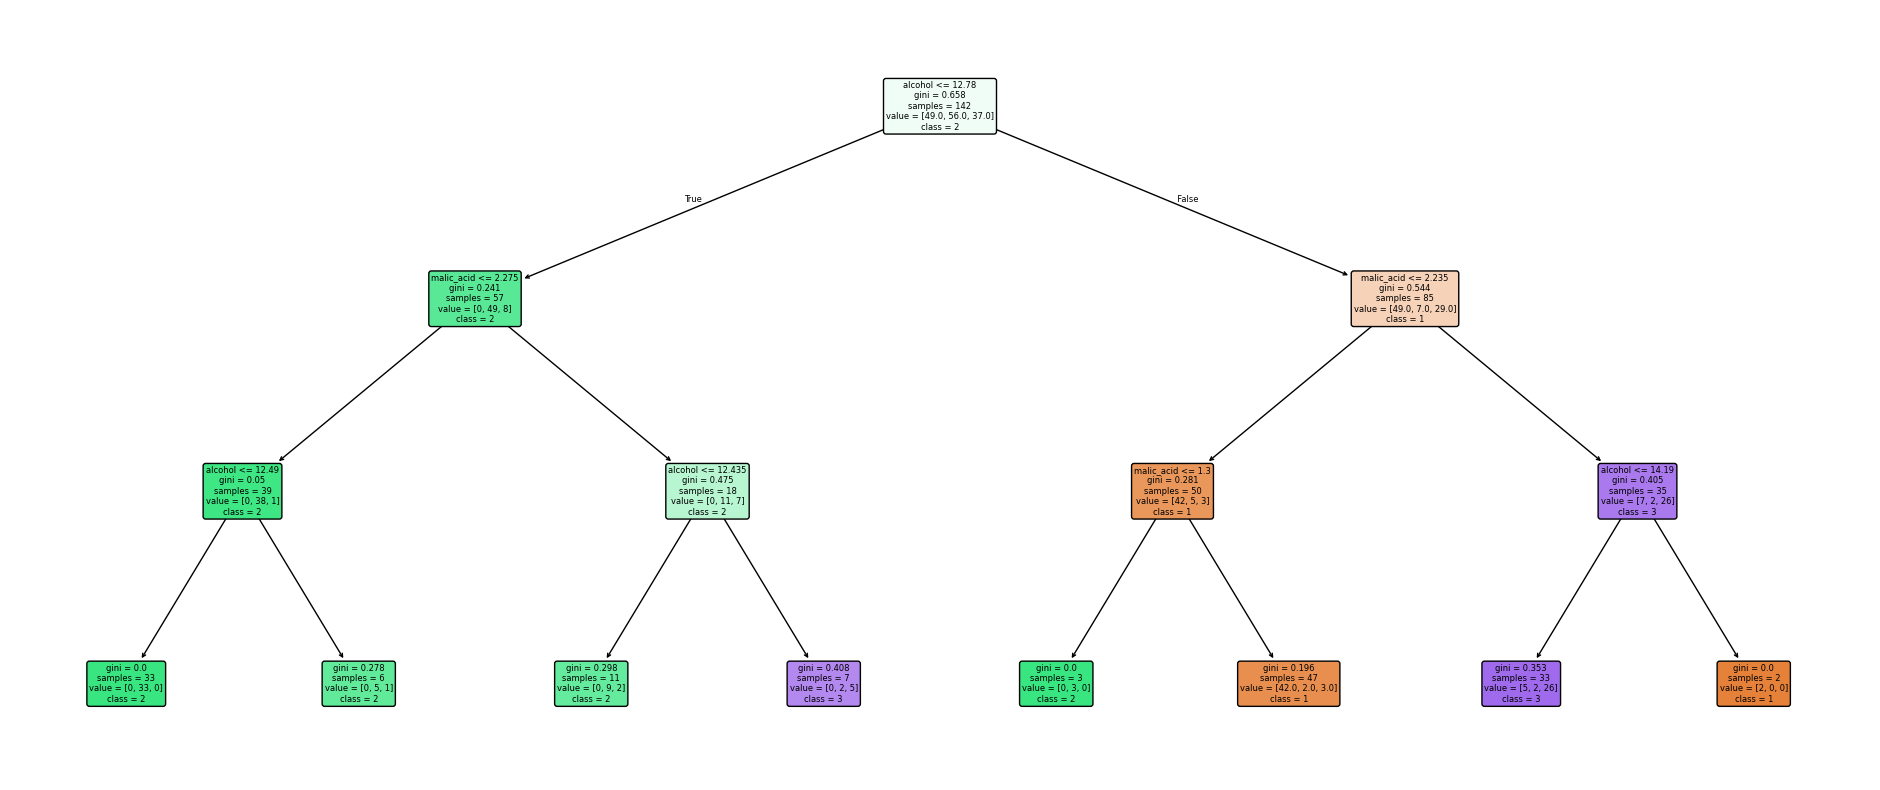

'max_depth=3,\n          filled=True,\n          rounded=True,\n          fontsize=6)'

In [5]:

# wine_tree.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 와인 데이터셋 로드
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)[['alcohol', 'malic_acid']]
y = wine.target

"""이때 데이터 셋을 sklearn.model_selection 모듈의 train_test_split을 사용해
8:2의 비율로 train:test로 분할하되, 난수(random_state)로 2222 값을 적용"""

# 데이터 8:2로 분할 (random_state=2222)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2222)

"""matplotlib.pyplot 모듈의
plot_tree를 사용하여 ‘depth=3’인 decision tree"""

# Decision Tree 모델 생성 및 학습 (max_depth=3)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=2222)
dt_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = dt_model.predict(X_test)

"""test
데이터 셋을 적용한 confusion matrix와 classification_report를 출력"""

# Confusion Matrix 출력
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

"""matplotlib.pyplot 모듈의
plot_tree를 사용하여 ‘depth=3’인 decision tree"""

# Decision Tree 시각화
# 그래프 크기 설정
plt.figure(figsize=(24, 10))
plot_tree(dt_model,
          feature_names=['alcohol', 'malic_acid'],
          class_names=['1', '2', '3'],
          max_depth=3,
          filled=True,
          rounded=True,fontsize=6)
plt.savefig('wine_decision_tree.png')
plt.show()

"""max_depth=3,
          filled=True,
          rounded=True,
          fontsize=6)"""

최적의 alcoholed malic acid 임계값: 5.61


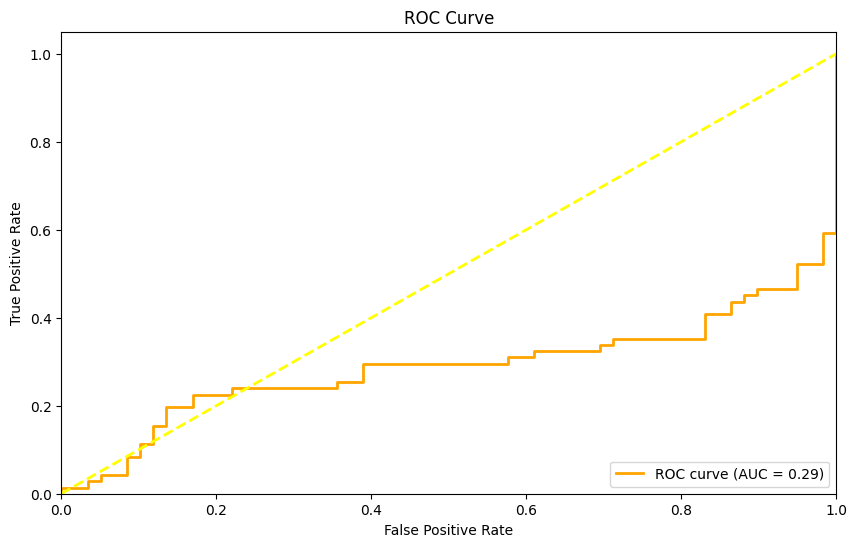

In [6]:
# wine_alcohol_roc.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 와인 데이터셋 로드
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

"""이번에는 와인 데이터셋에서 등급이 0과 1인 데이터만을 남기고
등급이 2인 데이터는 제거한 데이터 셋을 준비하시오"""

# 클래스 0과 1만 선택
#d['target'] = dataset.target
df = df[df['target'].isin([0, 1])]

# alcoholed malic acid 계산
def calculate_alcoholed_malic_acid(alcohol, malic_acid):
    return np.sqrt(alcohol * malic_acid)

#𝑎𝑙𝑐𝑜ℎ𝑜𝑙𝑒𝑑 𝑚𝑎𝑙𝑖𝑐 𝑎𝑐𝑖𝑑 = √𝑎𝑙𝑐𝑜ℎ𝑜𝑙 ∙ (𝑚𝑎𝑙𝑖𝑐 𝑎𝑐𝑖𝑑)

df['alcoholed_malic_acid'] = calculate_alcoholed_malic_acid(
    df['alcohol'], df['malic_acid']
)

# ROC 커브를 위한 데이터 준비
y_true = df['target']
scores = df['alcoholed_malic_acid']

"""" alcoholed malic acid라는 지표를 아래의 식을 통해 계산하여
활용하자. alcoholed malic acid 값을 9.0 ~ 24.0까지 0.1씩 증가시키면서 등급이 1인 와인을 찾아내는
경우의 ROC 곡선을 그려내고, 와인의 등급을 0과 1로 분류할 때 가장 높은 성능을 보이는 alcoholed
malic acid의 기준값(threshold)을 제시하시오"""

# 임계값 범위 설정 (9.0 ~ 24.0, 0.1 간격)
thresholds = np.arange(9.0, 24.1, 0.1)

"""
while은 필요없지않나? -> 그냥 범위 지정
# --- 예측값 생성 (몸무게가 threshold 이상이면 1, 아니면 0) ---
y_pred = []
for w in weight:
    if w >= threshold:
        y_pred.append(1)
    else:
        y_pred.append(0)
"""

# ROC 커브 계산
fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

# ROC 커브 그리기
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='orange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='yellow', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# 최적의 임계값 찾기
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = roc_thresholds[optimal_idx]

print(f"최적의 alcoholed malic acid 임계값: {optimal_threshold:.2f}")

plt.savefig('wine_roc_curve.png')
plt.show()



Confusion Matrix:
[[ 9  0  1]
 [ 1 13  1]
 [ 1  3  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.81      0.87      0.84        15
           2       0.78      0.64      0.70        11

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.80      0.81      0.80        36



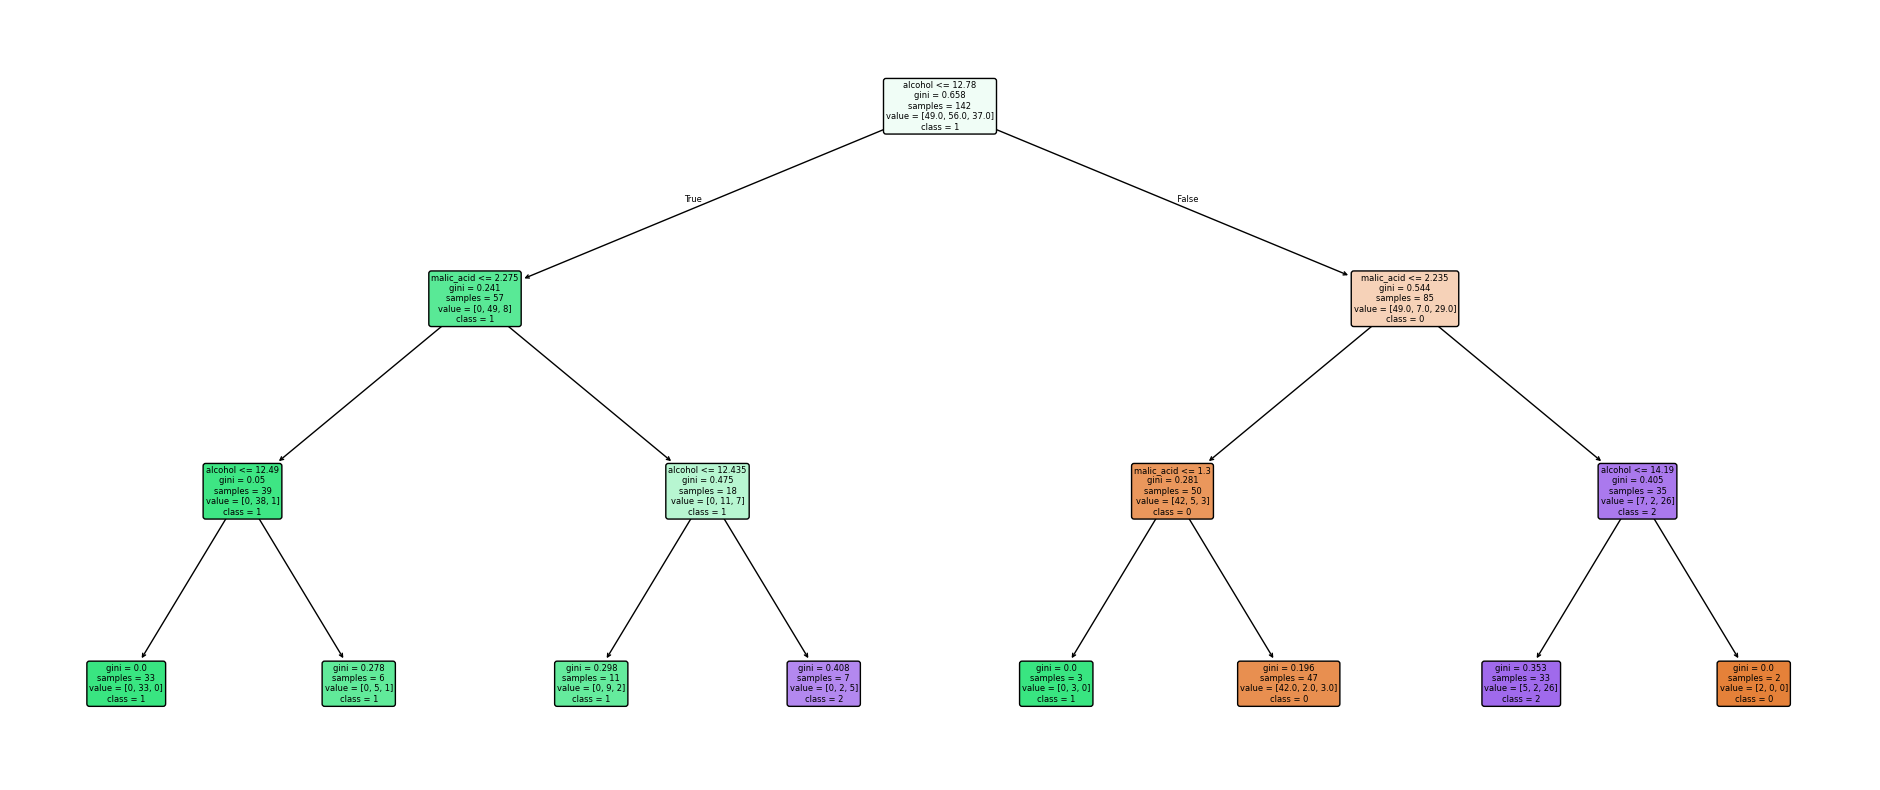

'max_depth=3,\n          filled=True,\n          rounded=True,\n          fontsize=6)'

In [8]:
# wine_tree.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 와인 데이터셋 로드
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)[['alcohol', 'malic_acid']]
y = wine.target

"""이때 데이터 셋을 sklearn.model_selection 모듈의 train_test_split을 사용해
8:2의 비율로 train:test로 분할하되, 난수(random_state)로 2222 값을 적용"""

"""데이터셋 분리 (test_size=0.2, random_state 고정)
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=2222)"""

# 데이터 8:2로 분할 (random_state=2222)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2222)

"""matplotlib.pyplot 모듈의
plot_tree를 사용하여 ‘depth=3’인 decision tree"""

# Decision Tree 모델 생성 및 학습 (max_depth=3)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=2222)
dt_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = dt_model.predict(X_test)

"""test
데이터 셋을 적용한 confusion matrix와 classification_report를 출력"""

# Confusion Matrix 출력
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

"""matplotlib.pyplot 모듈의
plot_tree를 사용하여 ‘depth=3’인 decision tree"""

# Decision Tree 시각화

# 그래프 크기 설정 와인등급 0~2
plt.figure(figsize=(24, 10))
plot_tree(dt_model,
          feature_names=['alcohol', 'malic_acid'],
          class_names=['0', '1', '2'],
          max_depth=3,
          filled=True,
          rounded=True,fontsize=6)
plt.savefig('wine_decision_tree.png')
plt.show()

"""max_depth=3,
          filled=True,
          rounded=True,
          fontsize=6)"""

최적의 alcoholed malic acid 임계값: 5.61


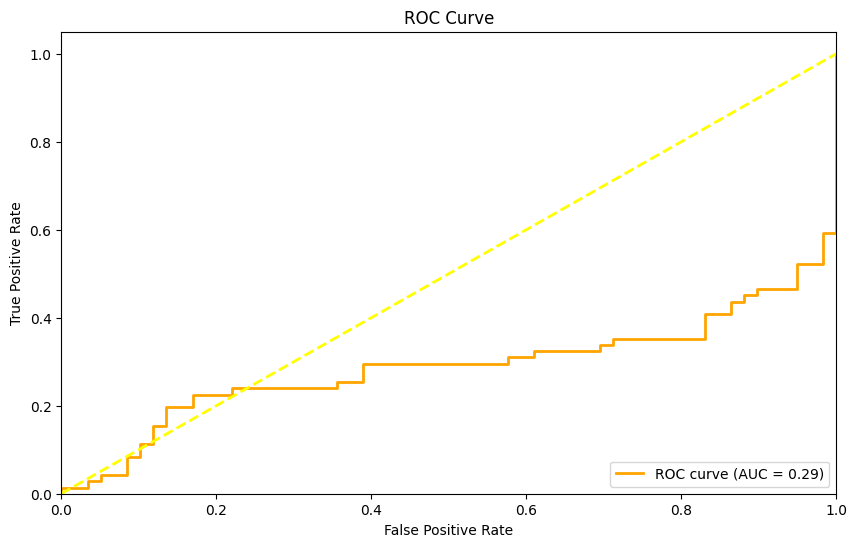

In [9]:
# wine_alcohol_roc.py

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 와인 데이터셋 로드
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

"""이번에는 와인 데이터셋에서 등급이 0과 1인 데이터만을 남기고
등급이 2인 데이터는 제거한 데이터 셋을 준비하시오"""

# 클래스 0과 1만 선택
#d['target'] = dataset.target
df = df[df['target'].isin([0, 1])]

# alcoholed malic acid 계산
def calculate_alcoholed_malic_acid(alcohol, malic_acid):
    return np.sqrt(alcohol * malic_acid)

#𝑎𝑙𝑐𝑜ℎ𝑜𝑙𝑒𝑑 𝑚𝑎𝑙𝑖𝑐 𝑎𝑐𝑖𝑑 = √𝑎𝑙𝑐𝑜ℎ𝑜𝑙 ∙ (𝑚𝑎𝑙𝑖𝑐 𝑎𝑐𝑖𝑑)

df['alcoholed_malic_acid'] = calculate_alcoholed_malic_acid(
    df['alcohol'], df['malic_acid']
)

# ROC 커브를 위한 데이터 준비
y_true = df['target']
scores = df['alcoholed_malic_acid']

"""" alcoholed malic acid라는 지표를 아래의 식을 통해 계산하여
활용하자. alcoholed malic acid 값을 9.0 ~ 24.0까지 0.1씩 증가시키면서 등급이 1인 와인을 찾아내는
경우의 ROC 곡선을 그려내고, 와인의 등급을 0과 1로 분류할 때 가장 높은 성능을 보이는 alcoholed
malic acid의 기준값(threshold)을 제시하시오"""

# 임계값 범위 설정 (9.0 ~ 24.0, 0.1 간격으로 증가)
thresholds = np.arange(9.0, 24.1, 0.1)

"""
while은 필요없지않나? -> 그냥 범위 지정
# --- 예측값 생성 (몸무게가 threshold 이상이면 1, 아니면 0) ---
y_pred = []
for w in weight:
    if w >= threshold:
        y_pred.append(1)
    else:
        y_pred.append(0)
"""

# ROC 커브 계산
fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

# ROC 커브 그리기
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='orange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='yellow', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# 최적의 임계값 찾기
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = roc_thresholds[optimal_idx]

print(f"최적의 alcoholed malic acid 임계값: {optimal_threshold:.2f}")

plt.savefig('wine_roc_curve.png')
plt.show()

# 등급이 1인 와인을 찾아내는, 표시를 해주는 함수? 그냥 1까지 나타내고 끊으면?

